In [1]:
# Cell 1: Install Dependencies
!pip install torchtext nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [2]:
# Cell 2: Import Libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import nltk
import random
import re
import string
import numpy as np
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [3]:
# Cell 3: Load Dataset (Cornell Movie Dialogs Corpus)
!wget https://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip
!unzip -o cornell_movie_dialogs_corpus.zip


--2025-03-31 11:18:39--  https://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip
Resolving www.cs.cornell.edu (www.cs.cornell.edu)... 132.236.207.53
Connecting to www.cs.cornell.edu (www.cs.cornell.edu)|132.236.207.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9916637 (9.5M) [application/zip]
Saving to: ‘cornell_movie_dialogs_corpus.zip’

cornell_movie_dialo 100%[===================>]   9.46M  14.4MB/s    in 0.7s    

2025-03-31 11:18:40 (14.4 MB/s) - ‘cornell_movie_dialogs_corpus.zip’ saved [9916637/9916637]

Archive:  cornell_movie_dialogs_corpus.zip
   creating: cornell movie-dialogs corpus/
  inflating: cornell movie-dialogs corpus/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/cornell movie-dialogs corpus/
  inflating: __MACOSX/cornell movie-dialogs corpus/._.DS_Store  
  inflating: cornell movie-dialogs corpus/chameleons.pdf  
  inflating: __MACOSX/cornell movie-dialogs corpus/._chameleons.pdf  
  inflating: cornell movi

In [8]:
# Cell 4: Parse Dataset
def load_conversations():
    with open("cornell movie-dialogs corpus/movie_lines.txt", encoding='utf-8', errors='ignore') as f:
        lines = f.read().split('\n')
    id2line = {}
    for line in lines:
        parts = line.split(" +++$+++ ")
        if len(parts) == 5:
            id2line[parts[0]] = parts[4]

    with open("cornell movie-dialogs corpus/movie_conversations.txt", encoding='utf-8', errors='ignore') as f:
        conversations = f.read().split('\n')

    pairs = []
    for conv in conversations:
        try:
            ids = eval(conv.split(" +++$+++ ")[-1])
            for i in range(len(ids) - 1):
                input_line = id2line[ids[i]]
                target_line = id2line[ids[i + 1]]
                pairs.append((input_line, target_line))
        except:
            pass
    return pairs

pairs = load_conversations()
print("Sample data pair:\n", pairs[0])
print("Total pairs:", len(pairs))

Sample data pair:
 ('Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.', "Well, I thought we'd start with pronunciation, if that's okay with you.")
Total pairs: 221616


In [10]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

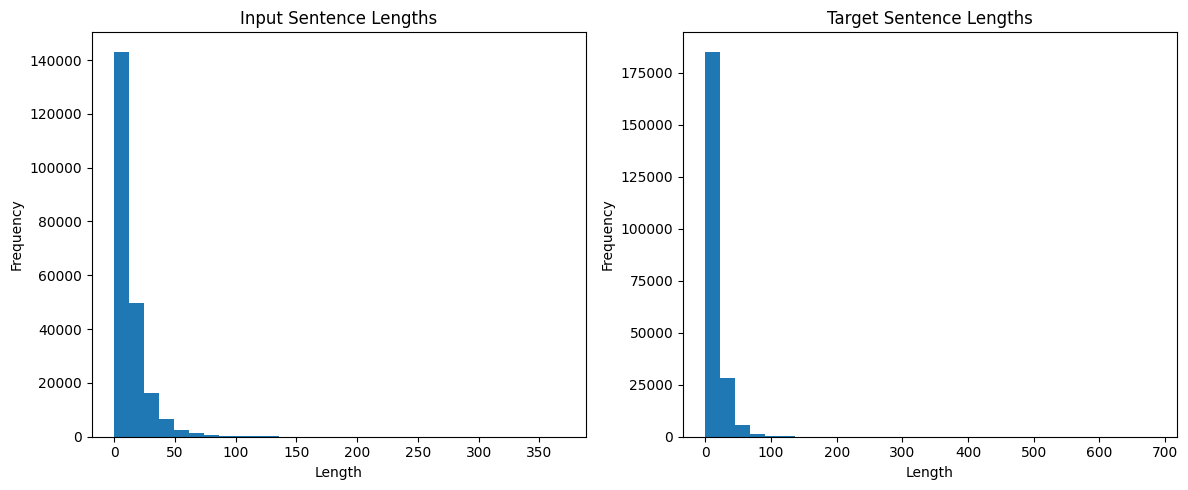

Average input length: 13.314449317738791
Average target length: 13.816299364666811
Max input length: 370
Max target length: 684


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate sentence lengths
input_lengths = [len(word_tokenize(pair[0])) for pair in pairs]
target_lengths = [len(word_tokenize(pair[1])) for pair in pairs]

# Create histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(input_lengths, bins=30)
plt.title('Input Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(target_lengths, bins=30)
plt.title('Target Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Further analysis (optional)
print("Average input length:", np.mean(input_lengths))
print("Average target length:", np.mean(target_lengths))
print("Max input length:", np.max(input_lengths))
print("Max target length:", np.max(target_lengths))


In [12]:
# Cell 5: Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)
    return text.strip()

pairs = [(clean_text(q), clean_text(a)) for q, a in pairs[:10000]]  # limit to 10k pairs for speed


In [14]:
# Cell 6: Tokenization and Vocabulary
all_words = []
for pair in pairs:
    all_words += word_tokenize(pair[0])
    all_words += word_tokenize(pair[1])

all_words = sorted(set(all_words))
word2idx = {word: idx+4 for idx, word in enumerate(all_words)}
word2idx["<PAD>"] = 0
word2idx["<SOS>"] = 1
word2idx["<EOS>"] = 2
word2idx["<UNK>"] = 3
idx2word = {idx: word for word, idx in word2idx.items()}

def encode_sentence(sent):
    return [word2idx.get(word, word2idx["<UNK>"]) for word in word_tokenize(sent)] + [word2idx["<EOS>"]]


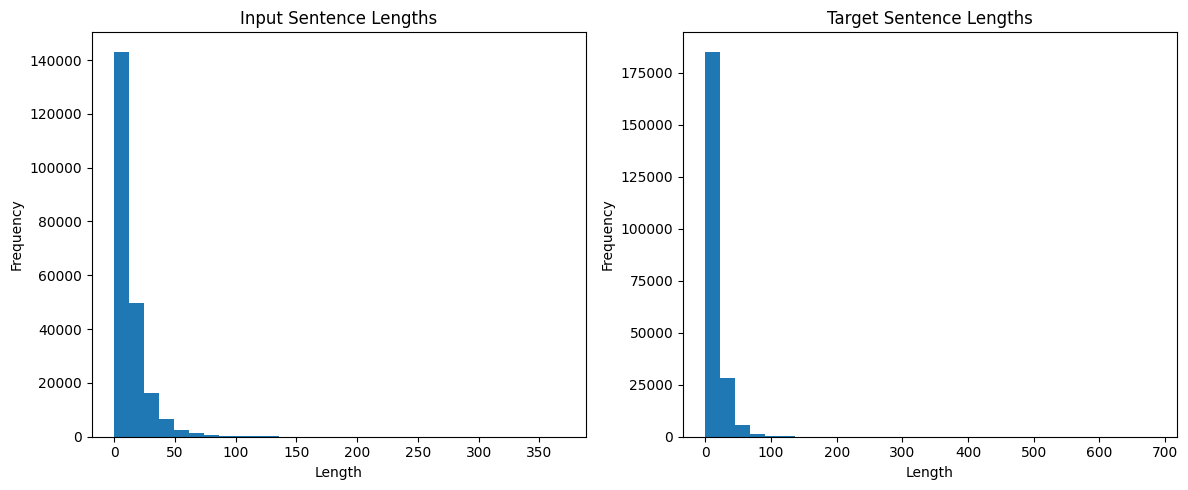

Average input length: 13.314449317738791
Average target length: 13.816299364666811
Max input length: 370
Max target length: 684


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Create histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(input_lengths, bins=30)
plt.title('Input Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(target_lengths, bins=30)
plt.title('Target Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Further analysis (optional)
print("Average input length:", np.mean(input_lengths))
print("Average target length:", np.mean(target_lengths))
print("Max input length:", np.max(input_lengths))
print("Max target length:", np.max(target_lengths))



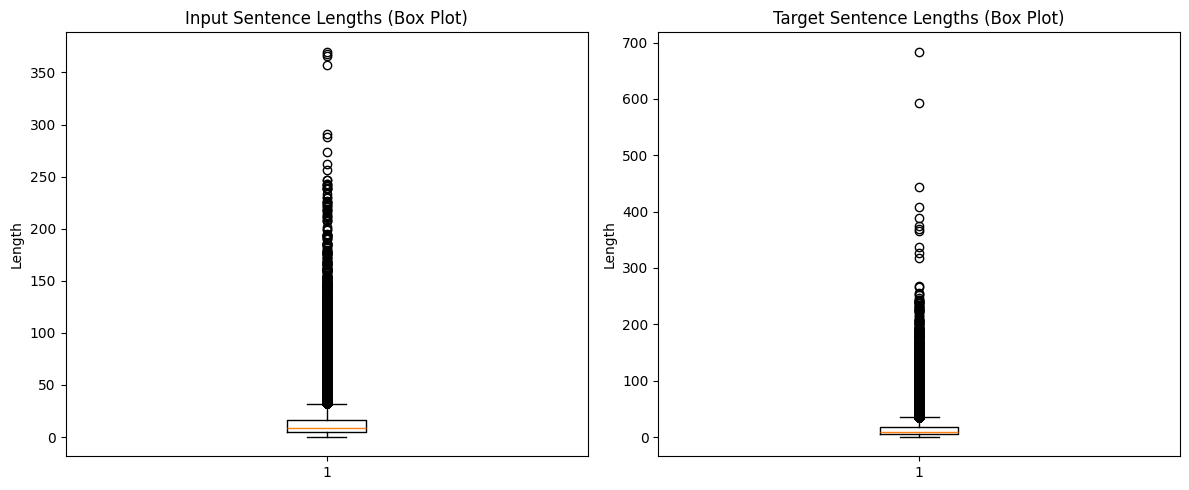

In [19]:
# Box plots for a more detailed view of the distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(input_lengths)
plt.title('Input Sentence Lengths (Box Plot)')
plt.ylabel('Length')


plt.subplot(1, 2, 2)
plt.boxplot(target_lengths)
plt.title('Target Sentence Lengths (Box Plot)')
plt.ylabel('Length')

plt.tight_layout()
plt.show()

In [20]:
# Cell 7: Dataset Preparation
class ChatDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        q, a = self.pairs[idx]
        return torch.tensor(encode_sentence(q)), torch.tensor(encode_sentence(a))

def collate_fn(batch):
    input_batch, target_batch = zip(*batch)
    input_batch = nn.utils.rnn.pad_sequence(input_batch, batch_first=True, padding_value=0)
    target_batch = nn.utils.rnn.pad_sequence(target_batch, batch_first=True, padding_value=0)
    return input_batch, target_batch

dataset = ChatDataset(pairs)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)


In [21]:
# Cell 8: Seq2Seq Model with Attention
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (h, c) = self.lstm(embedded)
        return outputs, h, c

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h, c):
        x = self.embedding(x)
        outputs, (h, c) = self.lstm(x, (h, c))
        return self.fc(outputs), h, c

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        encoder_outputs, h, c = self.encoder(src)
        output, _, _ = self.decoder(tgt[:, :-1], h, c)
        return output


In [22]:
# Cell 9: Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size = len(word2idx)
embed_size = 256
hidden_size = 512

encoder = Encoder(vocab_size, embed_size, hidden_size).to(device)
decoder = Decoder(vocab_size, embed_size, hidden_size).to(device)
model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
losses = []

for epoch in range(epochs):
    total_loss = 0
    for input_seq, target_seq in dataloader:
        input_seq, target_seq = input_seq.to(device), target_seq.to(device)
        output = model(input_seq, target_seq)

        loss = criterion(output.view(-1, vocab_size), target_seq[:, 1:].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/50], Loss: 5.8653
Epoch [2/50], Loss: 5.1170
Epoch [3/50], Loss: 4.7260
Epoch [4/50], Loss: 4.3440
Epoch [5/50], Loss: 3.9592
Epoch [6/50], Loss: 3.5649
Epoch [7/50], Loss: 3.1847
Epoch [8/50], Loss: 2.8244
Epoch [9/50], Loss: 2.4956
Epoch [10/50], Loss: 2.1935
Epoch [11/50], Loss: 1.9285
Epoch [12/50], Loss: 1.6941
Epoch [13/50], Loss: 1.4923
Epoch [14/50], Loss: 1.3193
Epoch [15/50], Loss: 1.1681
Epoch [16/50], Loss: 1.0480
Epoch [17/50], Loss: 0.9342
Epoch [18/50], Loss: 0.8395
Epoch [19/50], Loss: 0.7639
Epoch [20/50], Loss: 0.7010
Epoch [21/50], Loss: 0.6470
Epoch [22/50], Loss: 0.5999
Epoch [23/50], Loss: 0.5561
Epoch [24/50], Loss: 0.5231
Epoch [25/50], Loss: 0.4934
Epoch [26/50], Loss: 0.4636
Epoch [27/50], Loss: 0.4397
Epoch [28/50], Loss: 0.4164
Epoch [29/50], Loss: 0.4020
Epoch [30/50], Loss: 0.3819
Epoch [31/50], Loss: 0.3644
Epoch [32/50], Loss: 0.3454
Epoch [33/50], Loss: 0.3249
Epoch [34/50], Loss: 0.3047
Epoch [35/50], Loss: 0.2879
Epoch [36/50], Loss: 0.2756
E

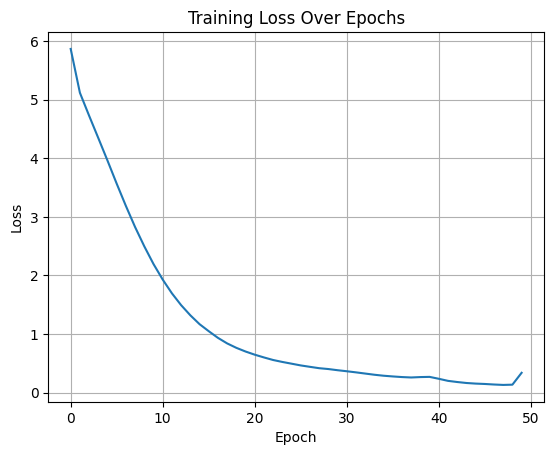

In [23]:
# Cell 10: Plot Loss
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()


In [24]:
# Cell 11: Save Model
torch.save(model.state_dict(), "chatbot_model.pth")


In [25]:
# Cell 12: Inference
def chat(model, input_text):
    model.eval()
    input_seq = torch.tensor(encode_sentence(clean_text(input_text))).unsqueeze(0).to(device)
    encoder_outputs, h, c = model.encoder(input_seq)

    tgt = torch.tensor([[word2idx["<SOS>"]]]).to(device)
    response = []

    for _ in range(20):
        out, h, c = model.decoder(tgt, h, c)
        pred_id = out.argmax(2)[:, -1].item()
        if pred_id == word2idx["<EOS>"]:
            break
        response.append(idx2word.get(pred_id, "<UNK>"))
        tgt = torch.cat([tgt, torch.tensor([[pred_id]]).to(device)], dim=1)

    return " ".join(response)

print(chat(model, "Hello, how are you?"))
print(chat(model, "What is your name?"))


do you will be given to any of out
in the course of an evening i think we re in one of a very kind of weather man i


In [26]:
# prompt: download trained model to local machine

from google.colab import files
files.download('chatbot_model.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# prompt: evaluate the model

# Cell 13: Evaluate the model (example interactions)

# Load the saved model
model.load_state_dict(torch.load("chatbot_model.pth"))
model.to(device)
model.eval()

# Example interactions
test_sentences = [
    "Hello",
    "How are you doing?",
    "What's your favorite movie?",
    "Tell me a joke.",
    "Goodbye"
]

for sentence in test_sentences:
  response = chat(model, sentence)
  print(f"User: {sentence}")
  print(f"Bot: {response}")
  print("---")


User: Hello
Bot: to be very simple box i m a huge strong fellow
---
User: How are you doing?
Bot: i m a negro
---
User: What's your favorite movie?
Bot: your wife may be right to the fact gracefully out of the way we can go double a fire dead
---
User: Tell me a joke.
Bot: love changes only and double an affair and jack went to that feeling as a fire press out that s
---
User: Goodbye
Bot: you want to get some food old women some old trying to education to hold it away
---


In [1]:
# prompt: evaluate the model

# Cell 13: Evaluate the model (example interactions)

# Load the saved model
model.load_state_dict(torch.load("chatbot_model.pth"))
model.to(device)
model.eval()

# Example interactions
test_sentences = [
    "Hello",
    "How are you doing?",
    "What's your favorite movie?",
    "Tell me a joke.",
    "Goodbye"
]

for sentence in test_sentences:
  response = chat(model, sentence)
  print(f"User: {sentence}")
  print(f"Bot: {response}")
  print("---")


NameError: name 'model' is not defined